In [3]:
import numpy as np
from scipy import special
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, SymLogNorm
import matplotlib.tri as tri
import auxiliary_funcs as af
import parameters as p
import collisions_vec as col

from scipy.optimize import fsolve


tau_o ions = 2123.1766532800625
ZPAR = 233.3333333333333 should match 233.33
ZPERP = 0.03055752047819377


# ERF/SLP FUNCS

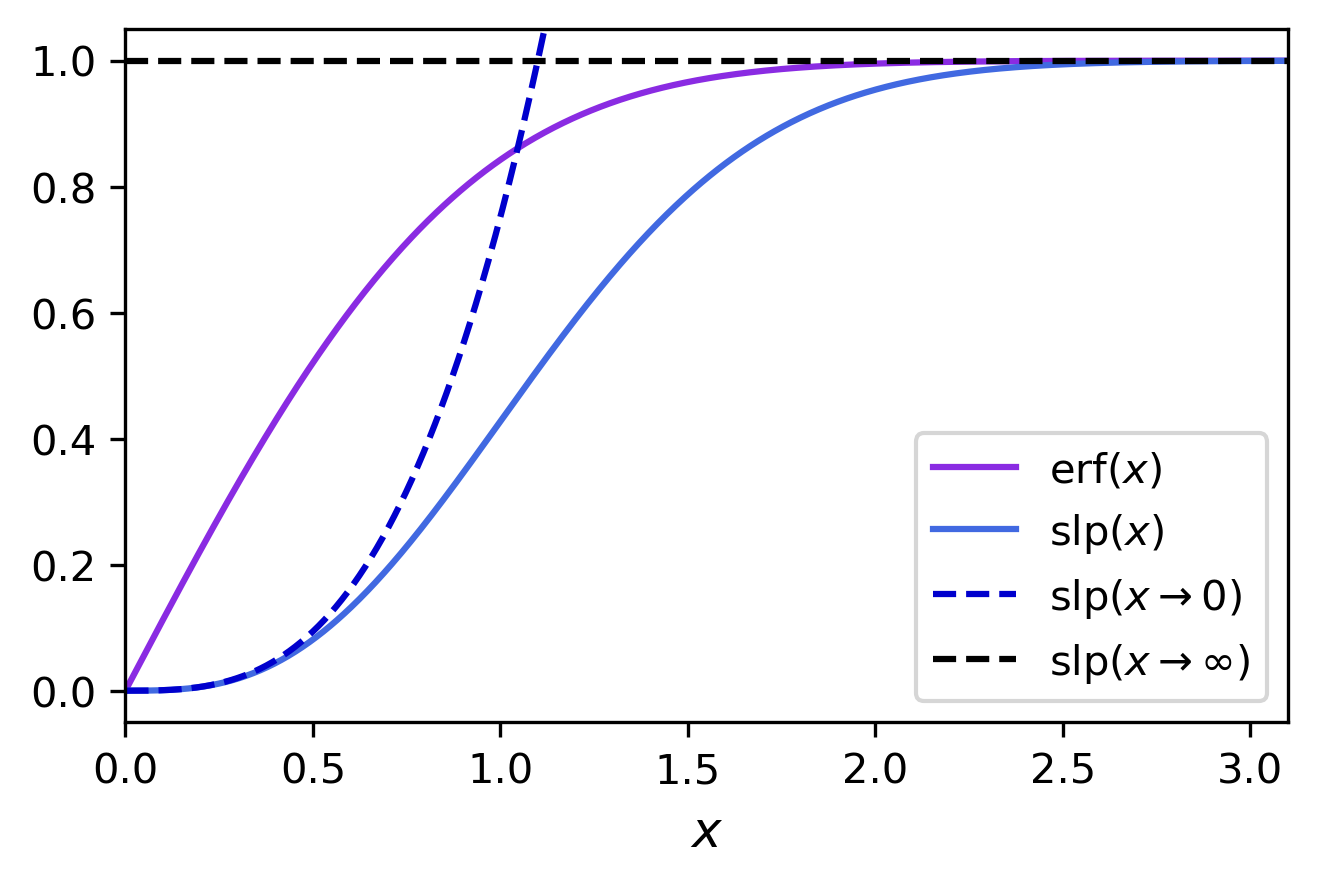

In [4]:
x = np.linspace(0, 3.1, 1000)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$', fontsize=12)
plt.xlim(0, 3.1)
plt.ylim(-0.05, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.plot(x, special.erf(x), label=r'erf$\left(x\right)$', color='blueviolet')
plt.plot(x, af.slp(x), label=r'slp$\left(x\right)$', color='royalblue')
plt.plot(x, 4 / (3 * np.sqrt(np.pi)) * x**3, label=r'slp$\left(x \rightarrow 0\right)$', linestyle='--', color='mediumblue')
plt.axhline(1, linestyle='--', color='black', label=r'slp$\left(x\rightarrow \infty \right) $')
plt.legend(fontsize=10)
plt.show()

# MESA DAME TEMPERATURE 

In [5]:
# ASIM X FUNCTIONS
def Asimx(x): 
    A_a = - p.ZPAR * af.wparb_slp(x) / x**2 
    A_geom = - af.wb_slp(x) / (2 * x**4) + 2 / (x * np.sqrt(np.pi)) * af.wb_cube_exp(x)
    return A_a + A_geom

def Asimx_nogeom(x): 
    return - p.ZPAR * af.wparb_slp(x) / x**2 


[0.05631001]


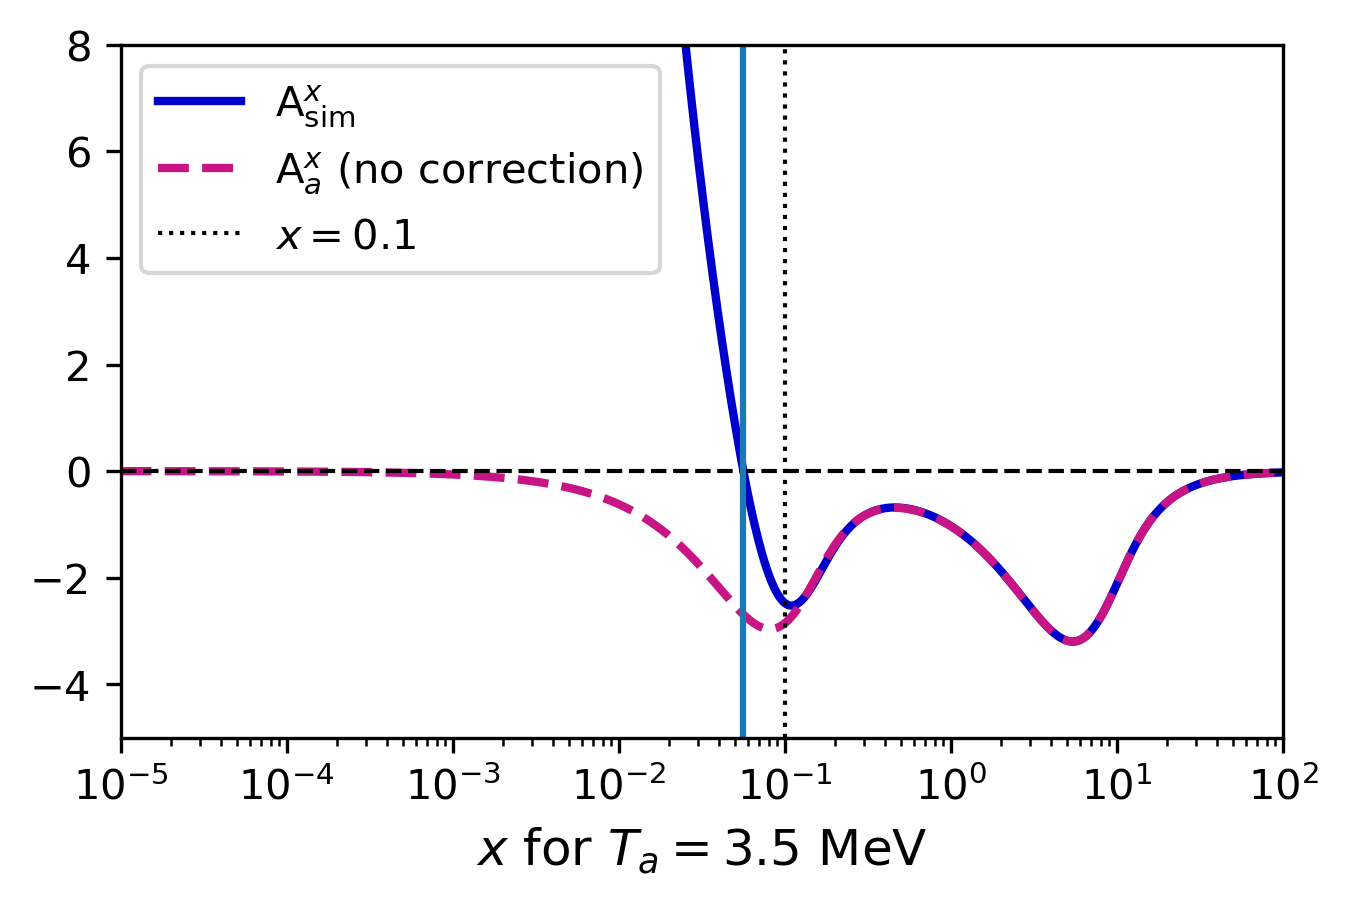

In [6]:
# PLOTS 
# x = np.linspace(1e-5, 100, 1000)
x = np.logspace(-5, 2, 1000)
root = fsolve(Asimx, x0=0.055)
print(root)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$ for $T_a = 3.5~\text{MeV}$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-5, 8)
plt.xlim(1e-5, 100)
plt.plot(x, Asimx(x), color='mediumblue', label=r'A$_{\text{sim}}^x$', linewidth=2)
plt.plot(x, Asimx_nogeom(x), color='mediumvioletred', label=r'A$_{a}^x$ (no correction)', linewidth=2, linestyle='--')
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.axvline(0.1, linestyle=':', color='black', linewidth=1, label=r'$x=0.1$')
plt.axvline(root)
plt.xscale('log')
plt.legend(fontsize=10)
plt.show()

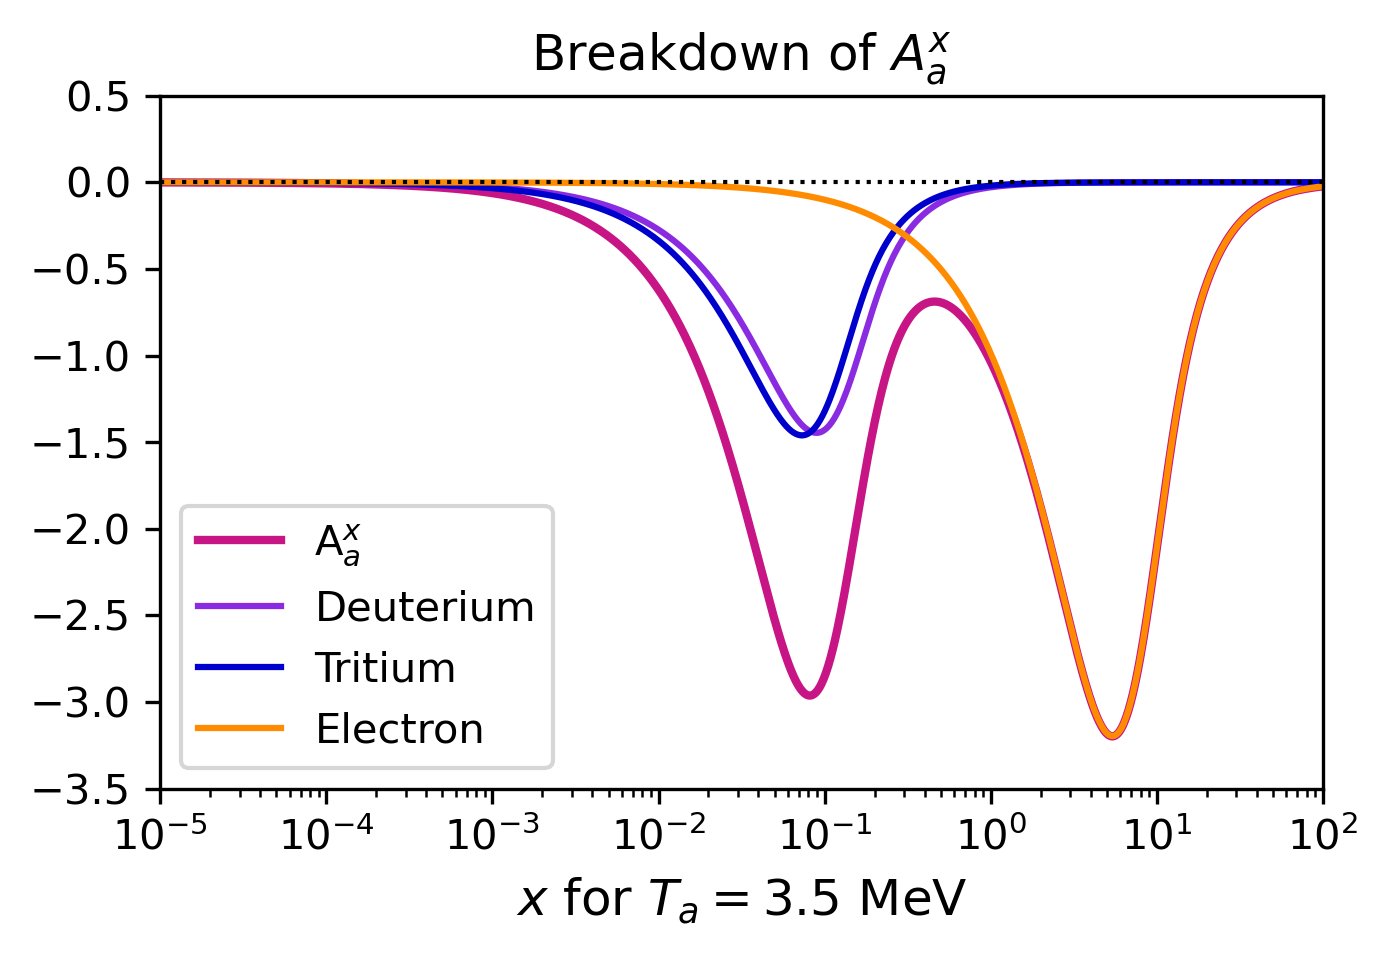

In [7]:
# x = np.linspace(1e-5, 100, 1000)
x = np.logspace(-5, 2, 1000)

plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$ for $T_a = 3.5~\text{MeV}$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-3.5, 0.5)
plt.xlim(1e-5, 100)
plt.plot(x, Asimx_nogeom(x), color='mediumvioletred', label=r'A$_{a}^x$', linewidth=2)
plt.plot(x, -p.ZPAR * af.slp(x * p.V_TH_A/p.V_TH_D) * p.C_ad/p.MASS_DEUT / p.WPAR_B_DEN / x**2, label=r'Deuterium', color='blueviolet')
plt.plot(x, -p.ZPAR * af.slp(x * p.V_TH_A/p.V_TH_T) * p.C_at/p.MASS_TRIT / p.WPAR_B_DEN / x**2, label=r'Tritium', color='mediumblue')
plt.plot(x, -p.ZPAR * af.slp(x * p.V_TH_A/p.V_TH_E) * p.C_ae/p.MASS_ELEC / p.WPAR_B_DEN / x**2, label=r'Electron', color='darkorange')
plt.axhline(0, linestyle=':', color='black', linewidth=1)
plt.xscale('log')
plt.legend(fontsize=10)
plt.title(r'Breakdown of $A^x_a$', fontsize=12)
plt.show()

In [8]:
def Asimxi(x,xi=0.5): 
    return - 2 * xi / x**3 * (p.ZPERP * af.wperpb_erf(x) - 1 / (4 * x**2) * af.wb_slp(x))

def Asimhighxi(x,xi=0.5): 
    return - 2 * p.ZPERP * xi / x**3

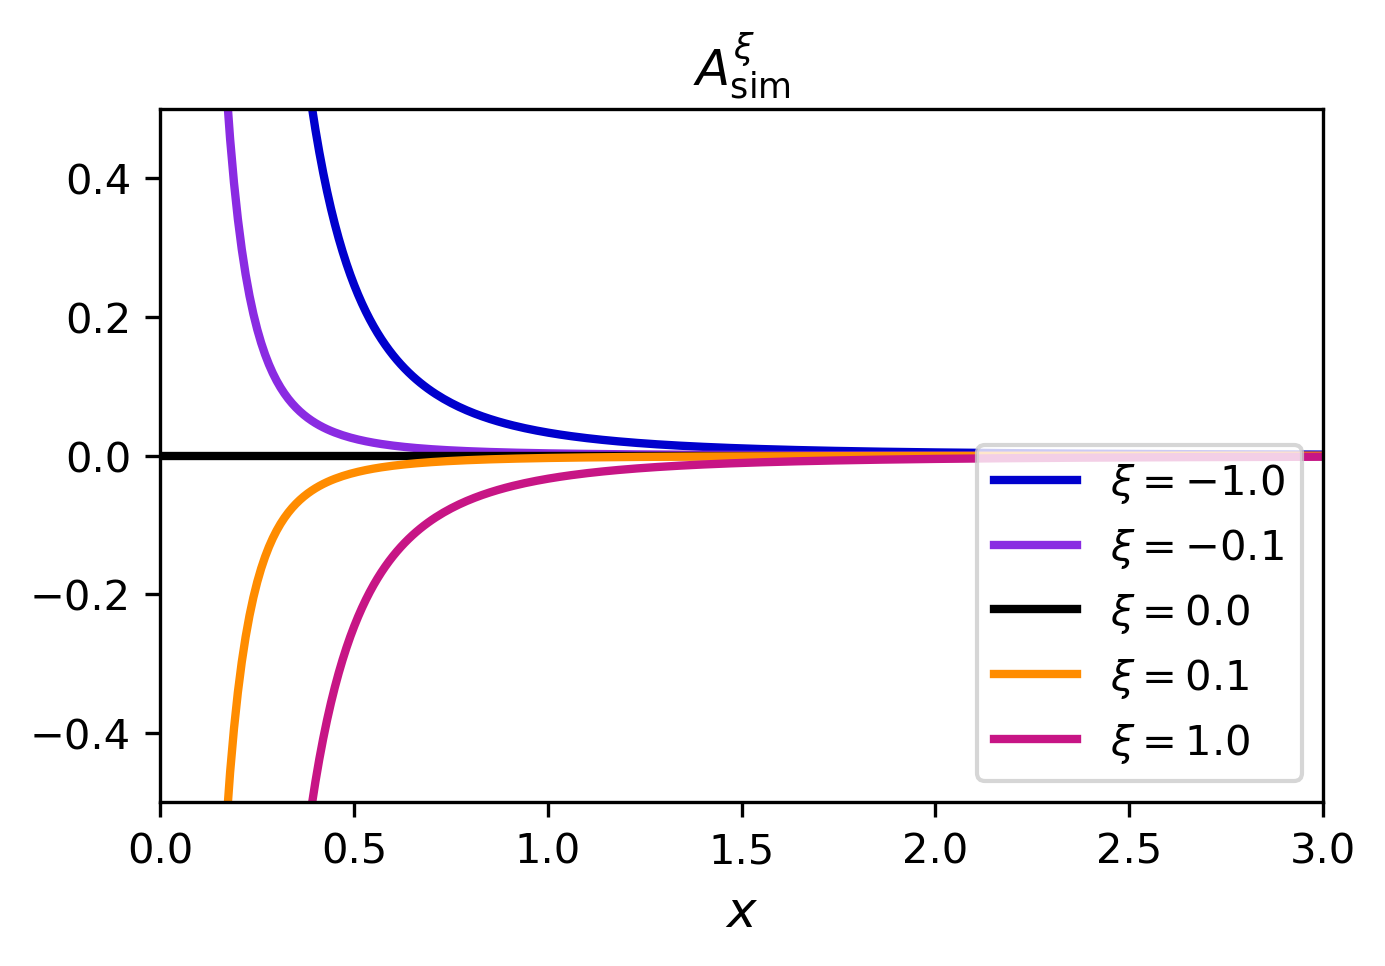

In [9]:
# plot, different values, -1, -0.5, 0, 0.5, 1, red, orange black purple blue
xvals = np.linspace(1e-8, 10, 1000)
plt.figure(figsize=(5, 3), dpi=300)
plt.xlabel(r'$x$', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0,3)
plt.ylim(-0.5, 0.5)
plt.plot(xvals, Asimxi(xvals, xi=-1.0), color='mediumblue', label=r'$\xi=-1.0$', linewidth=2)
plt.plot(xvals, Asimxi(xvals, xi=-0.1), color='blueviolet', label=r'$\xi=-0.1$', linewidth=2)
plt.axhline(0, color='black', linewidth=2, label=r'$\xi=0.0$')
plt.plot(xvals, Asimxi(xvals, xi=0.1), color='darkorange', label=r'$\xi=0.1$', linewidth=2)
plt.plot(xvals, Asimxi(xvals, xi=1.0), color='mediumvioletred', label=r'$\xi=1.0$', linewidth=2)
plt.legend(fontsize=10, loc='lower right')
plt.title(r'$A_\text{sim}^\xi$', fontsize=12)
plt.show()


/var/folders/5l/cp2w2dsj569686mqpbzbm61c0000gn/T/ipykernel_93814/3215157465.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('RdBu_r', n_bins)
/Users/gretali/miniforge3/envs/alphachanneling/lib/python3.10/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


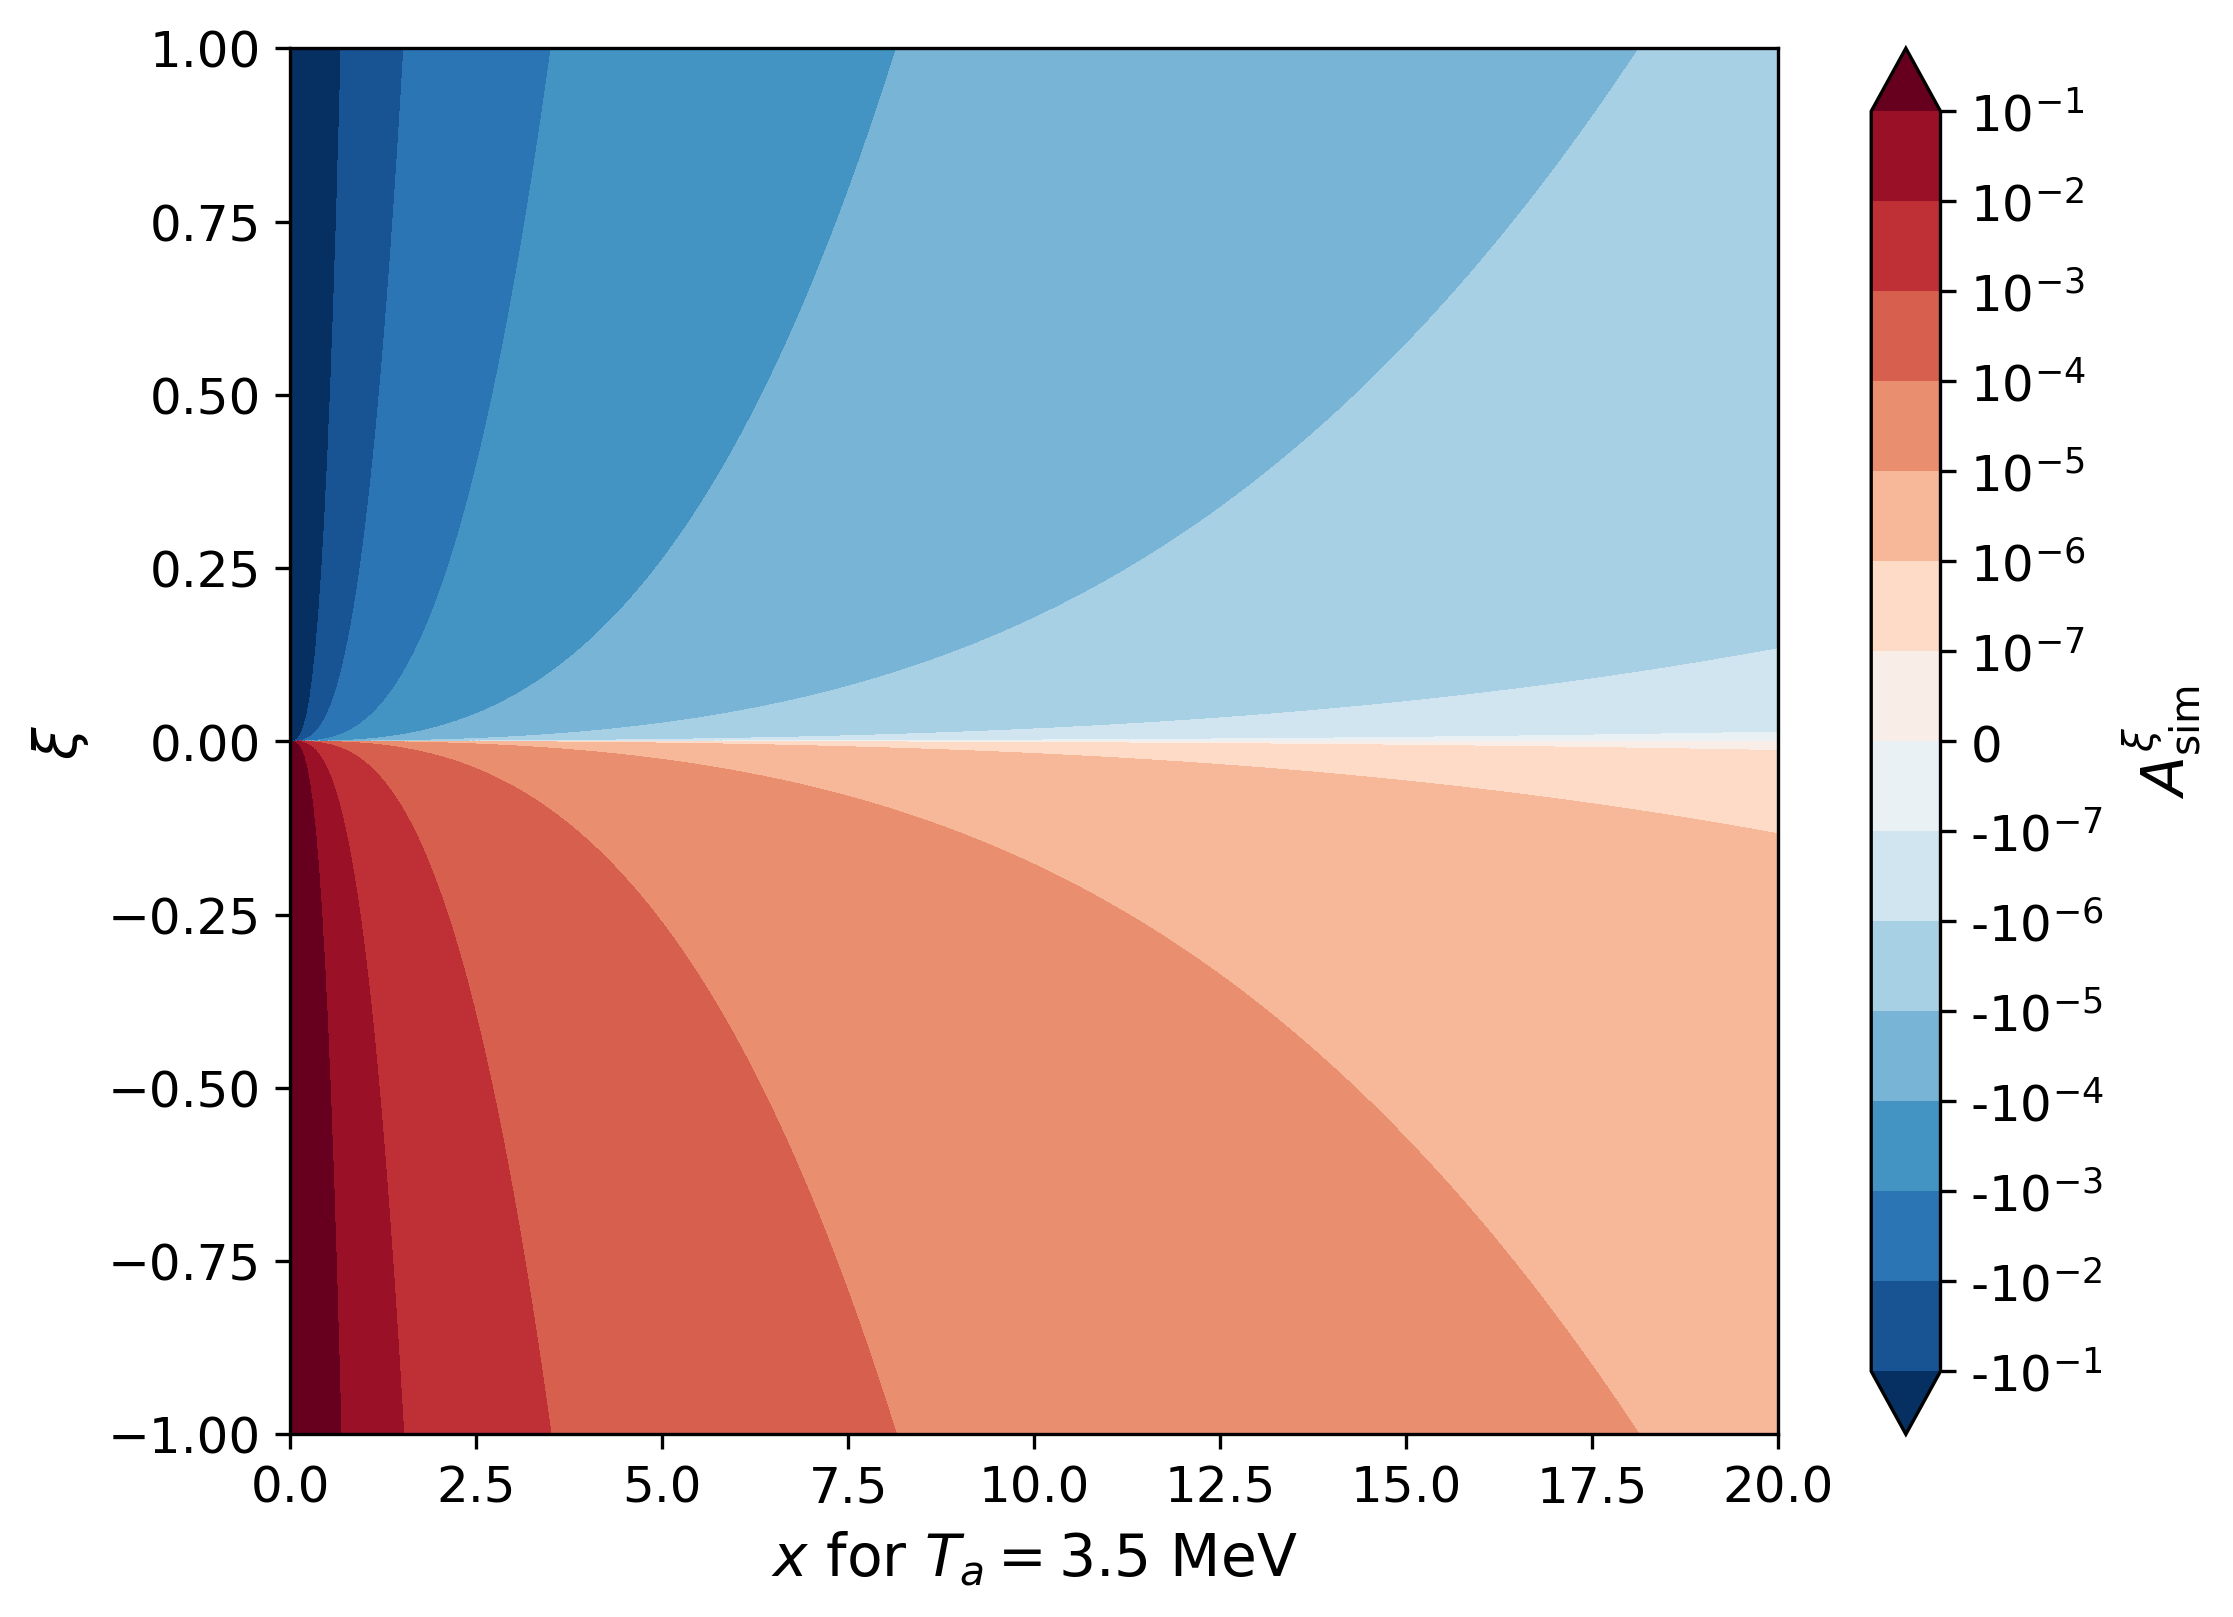

In [10]:
levels = np.array([-1e-1,-1e-2, -1e-3, -1e-4, -1e-5, -1e-6, -1e-7, 0.0, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
n_bins = len(levels) + 1
base_cmap = plt.cm.get_cmap('RdBu_r', n_bins)
normed_bounds = (levels - levels.min()) / (levels.max() - levels.min())
colors = base_cmap(np.linspace(0, 1, n_bins))
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=levels, ncolors=n_bins, extend='both')

x_values = np.linspace(1e-10, 20, 500)  
xi_values = np.linspace(-1, 1, 500)
X, XI = np.meshgrid(x_values, xi_values)
Z = Asimxi(X, XI) 
x_flat = X.flatten()
xi_flat = XI.flatten()
z_flat = Z.flatten()

plt.figure(figsize=(8,6), dpi=300)
tri = plt.tricontourf(x_flat, xi_flat, z_flat, cmap=cmap, norm=norm, levels=levels, extend='both')
cbar = plt.colorbar(tri, extend='both', ticks=levels)
tick_labels = [r'$0$' if v==0 else f'$10^{{{int(np.log10(abs(v)))}}}$' for v in levels]
tick_labels = [label if v>=0 else '-' + label for v, label in zip(levels, tick_labels)]
cbar.set_ticklabels(tick_labels, fontsize=12)
cbar.set_label(label=r'$A_\text{sim}^{\xi}$', fontsize=14)
plt.xlabel(r'$x$ for $T_a = 3.5~\text{MeV}$', fontsize=14)
plt.ylabel(r'$\xi$', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()